In [30]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load the CSV file
def load_data(file_path):
    df = pd.read_csv(file_path, parse_dates=['Date'])
    df = df.sort_values('Date')
    X = df[['Open', 'High', 'Low', 'Volume']]  # Features
    y = df['Close']  # Target (Close price)
    return X, y, df['Date']

# Prepare the data for training
# Prepare the data for training
def prepare_data(X, y):
    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Scale the features (important for KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Train the KNN model
def train_knn(X_train, y_train, n_neighbors=5):
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    return knn

# Evaluate the model
def evaluate_model(knn, X_test, y_test):
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'Mean Squared Error: {mse:.4f}')
    return y_pred

# Plot actual vs predicted stock prices
def plot_predictions(dates, y_test, y_pred):
    plt.figure(figsize=(10,6))
    plt.plot(dates, y_test, label='Actual Close Prices', color='blue')
    plt.plot(dates, y_pred, label='Predicted Close Prices', color='red')
    plt.title('Actual vs Predicted Close Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Predict the Next Day's Close Price
def predict_next_day(knn, scaler, last_row):
    # Scale the features of the last row (Open, High, Low, Volume)
    last_row_scaled = scaler.transform([last_row])  # Needs 2D array as input

    # Predict the next day's close price
    next_day_pred = knn.predict(last_row_scaled)
    print(f"Predicted Next Day Close Price: {next_day_pred[0]:.2f}")
    return next_day_pred[0]

In [31]:
# Load and Prepare Data
file_path = '../data/BRK.csv'  # Replace this with the path to your CSV file
X, y, dates = load_data(file_path)
X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

In [32]:
# Train the KNN Model
knn = train_knn(X_train, y_train)

In [33]:
# Evaluate the Model
y_pred = evaluate_model(knn, X_test, y_test)

Mean Squared Error: 842.2037


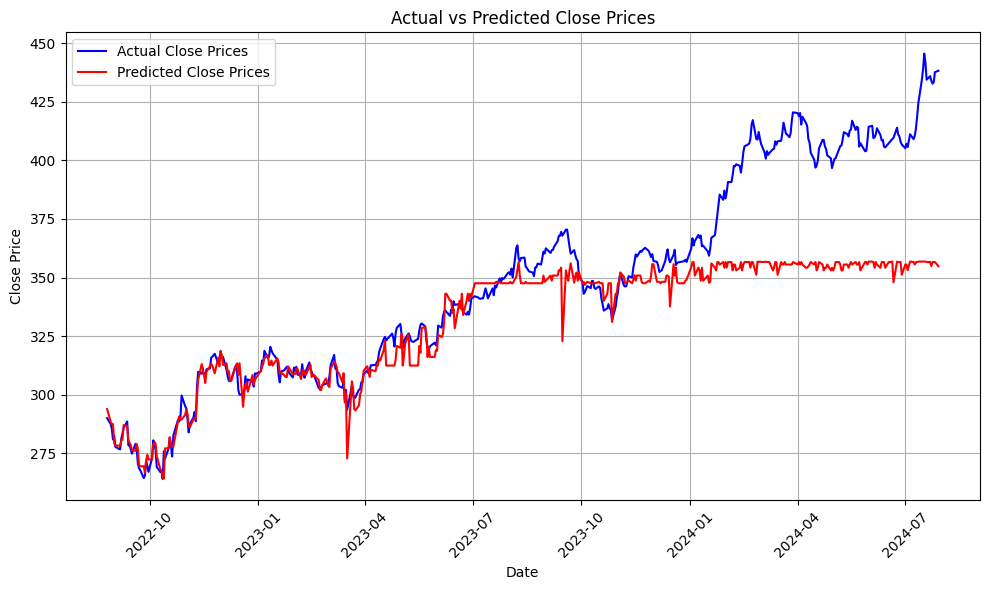

In [34]:
# Plot Actual vs Predicted Prices
plot_predictions(dates[-len(y_test):], y_test, y_pred)

In [35]:
# After training and evaluating the model
last_row = X.iloc[-1].values  # The latest 'Open', 'High', 'Low', 'Volume' data
predict_next_day(knn, scaler, last_row)  # Predict the next day's Close price

Predicted Next Day Close Price: 354.81


c:\Users\bhumi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


354.81199340820314